# Lib

In [23]:
import time
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib
from tqdm import tqdm

from face_recognition import *

import warnings
warnings.filterwarnings("ignore")

# Path

In [9]:
TEST_DIR = Path("../../dataset_face_recognition/processed/test")
MODEL_DIR = Path("../../model")
FISHER_PATH = MODEL_DIR / "fisherfaces_model.pkl"
LBPH_MODEL_PATH = MODEL_DIR / "lbph_model.yml"
LBPH_CLASSES_PATH = MODEL_DIR / "lbph_class_names.json"

# Func

In [ ]:
def visualize_random_predictions(
    fisher_dict, lbph_model, raw_test_dir, face_detector, n_samples=6, cols=3
):
    pca = fisher_dict["pca"]
    lda = fisher_dict["lda"]
    classifier = fisher_dict["classifier"]
    class_names = fisher_dict["class_names"]

    raw_test_dir = Path(raw_test_dir)
    all_test_images = []

    for person_name in class_names:
        person_dir = raw_test_dir / person_name
        if not person_dir.exists():
            continue
        for img_path in person_dir.glob("*.*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                all_test_images.append((str(img_path), person_name))

    if len(all_test_images) == 0:
        print("Không tìm thấy ảnh nào trong thư mục Test Gốc!")
        return

    random.shuffle(all_test_images)

    valid_samples = []

    for img_path, true_name in all_test_images:
        img_raw = cv2.imread(img_path)
        if img_raw is None:
            continue
        processed_img = preprocess_face(img_raw, face_detector, target_size=(250, 250))
        if processed_img is not None:
            valid_samples.append((img_raw, processed_img, true_name))
            if len(valid_samples) == n_samples:
                break
    if len(valid_samples) == 0:
        print("Không tìm thấy khuôn mặt nào trong các ảnh Test!")
        return

    rows = (len(valid_samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 5))

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, (img_raw, processed_img, true_name) in enumerate(valid_samples):
        ax = axes[i]
        img_flat = processed_img.flatten().reshape(1, -1)
        X_pca = pca.transform(img_flat)
        X_lda = lda.transform(X_pca)
        fisher_pred_idx = classifier.predict(X_lda)[0]
        fisher_pred_name = class_names[fisher_pred_idx]
        lbph_pred_idx, confidence = lbph_model.predict(processed_img)
        lbph_pred_name = class_names[lbph_pred_idx]
        title_text = (
            f"Thực tế: {true_name}\n"
            f"Fisher: {fisher_pred_name}\n"
            f"LBPH: {lbph_pred_name}"
        )

        if fisher_pred_name != true_name and lbph_pred_name != true_name:
            title_color = "red"
        elif fisher_pred_name == true_name and lbph_pred_name == true_name:
            title_color = "green"
        else:
            title_color = "grey"

        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.axis("off")
        ax.set_title(
            title_text, color=title_color, fontsize=11, fontweight="bold", pad=10
        )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Model

In [7]:
fisher_data = joblib.load(FISHER_PATH)
pca = fisher_data["pca"]
lda = fisher_data["lda"]
classifier = fisher_data["classifier"]
class_names = fisher_data["class_names"]

In [10]:
lbph_model = cv2.face.LBPHFaceRecognizer_create()
lbph_model.read(str(LBPH_MODEL_PATH))

# Data

In [11]:
X_test_2d = []  # LBPH
X_test_1d = []  # Fisherfaces
y_test = []

for label_int, person_name in enumerate(class_names):
    person_dir = TEST_DIR / person_name
    if not person_dir.exists():
        continue

    for img_path in person_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            X_test_2d.append(img)
            X_test_1d.append(img.flatten())
            y_test.append(label_int)

X_test_1d = np.array(X_test_1d)
y_test = np.array(y_test)

In [12]:
# BENCHMARK FISHERFACES
start_time = time.time()

# Pipeline Fisherfaces
X_test_pca = pca.transform(X_test_1d)
X_test_lda = lda.transform(X_test_pca)
y_pred_fisher = classifier.predict(X_test_lda)

fisher_time = time.time() - start_time
fisher_fps = len(y_test) / fisher_time

In [13]:
# BENCHMARK LBPH
start_time = time.time()

y_pred_lbph = []
for img in X_test_2d:
    label, _ = lbph_model.predict(img)
    y_pred_lbph.append(label)
    
lbph_time = time.time() - start_time
lbph_fps = len(y_test) / lbph_time

In [22]:
result = pd.DataFrame(
    {
        "Model": ["Fisherfaces", "LBPH"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_fisher),
            accuracy_score(y_test, y_pred_lbph),
        ],
        "Precision": [
            precision_score(y_test, y_pred_fisher, average="macro"),
            precision_score(y_test, y_pred_lbph, average="macro"),
        ],
        "Recall": [
            recall_score(y_test, y_pred_fisher, average="macro"),
            recall_score(y_test, y_pred_lbph, average="macro"),
        ],
        "F1 Score": [
            f1_score(y_test, y_pred_fisher, average="macro"),
            f1_score(y_test, y_pred_lbph, average="macro"),
        ],
    }
)
result.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Fisherfaces,0.9573,0.9633,0.9551,0.9584
1,LBPH,0.9617,0.9644,0.9601,0.9615


# Predict

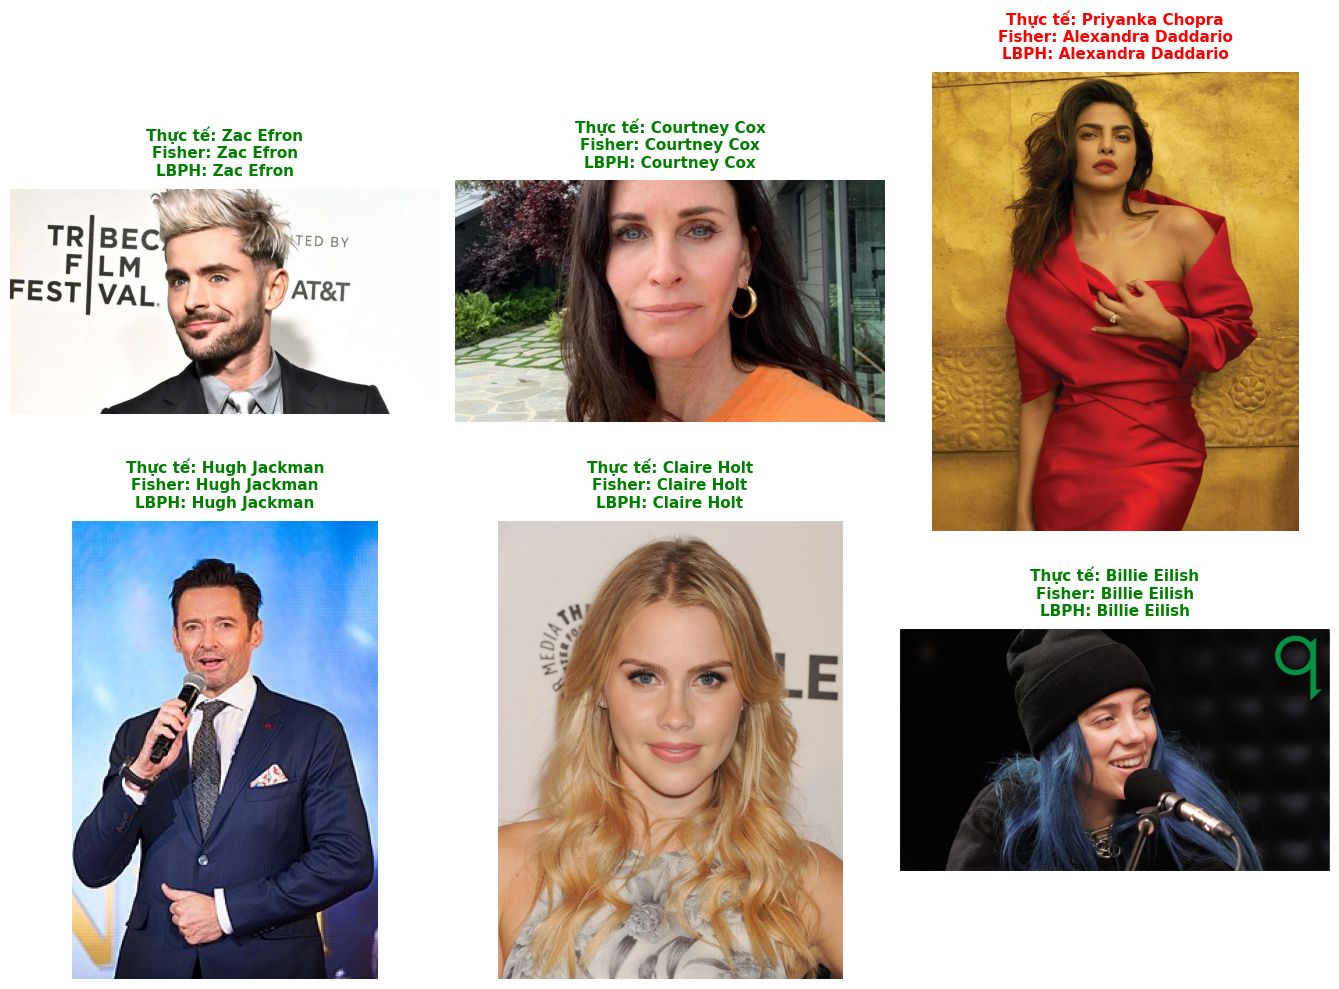

In [32]:
detector = HaarDetector()

visualize_random_predictions(
    fisher_dict=fisher_data, 
    lbph_model=lbph_model, 
    raw_test_dir="../../dataset_face_recognition/test", 
    face_detector=detector, 
    n_samples=6, 
    cols=3
)